In [1]:
pip install tensorflow pandas numpy yfinance scikit-learn matplotlib ta-lib sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install TA_Lib-0.4.28-cp311-cp311-win_amd64.whl

Processing c:\users\dmlxo\documents\github\ai-stock\models\ta_lib-0.4.28-cp311-cp311-win_amd64.whlNote: you may need to restart the kernel to use updated packages.

TA-Lib is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


[*********************100%***********************]  1 of 1 completed


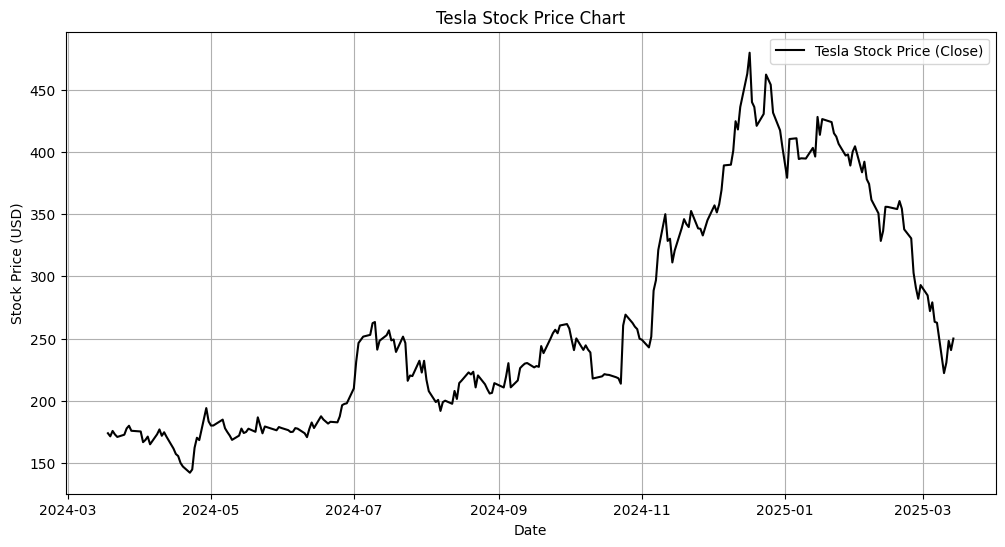

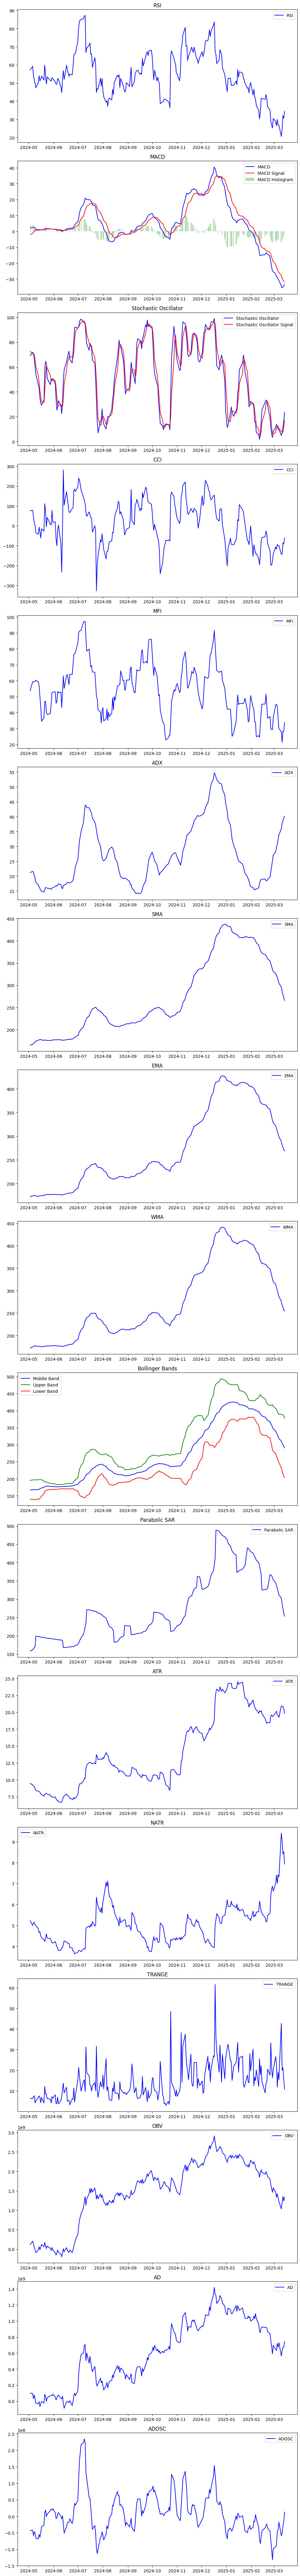

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt

# 티커 설정
ticker = "TSLA"

# 데이터 수집 (기간 조정 가능)
df = yf.download(ticker, start="2024-03-17", end="2025-03-17", interval="1d")

# 기본 컬럼 선택
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# 데이터를 np.float64 자료형의 1D numpy 배열로 변환
close = np.array(df['Close'], dtype=np.float64).ravel()
high = np.array(df['High'], dtype=np.float64).ravel()
low = np.array(df['Low'], dtype=np.float64).ravel()
volume = np.array(df['Volume'], dtype=np.float64).ravel()

# 각종 기술적 지표 계산
rsi = talib.RSI(close, timeperiod=14)
macd, macd_signal, macd_hist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
slowk, slowd = talib.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
cci = talib.CCI(high, low, close, timeperiod=14)
mfi = talib.MFI(high, low, close, volume, timeperiod=14)
adx = talib.ADX(high, low, close, timeperiod=14)
sma = talib.SMA(close, timeperiod=14)
ema = talib.EMA(close, timeperiod=14)
wma = talib.WMA(close, timeperiod=14)
upperband, middleband, lowerband = talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
sar = talib.SAR(high, low, acceleration=0.02, maximum=0.2)
atr = talib.ATR(high, low, close, timeperiod=14)
natr = talib.NATR(high, low, close, timeperiod=14)
trange = talib.TRANGE(high, low, close)
obv = talib.OBV(close, volume)
ad = talib.AD(high, low, close, volume)
adosc = talib.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

# 지표들을 DataFrame에 추가
ind = pd.DataFrame({
    'RSI': rsi,
    'MACD': macd,
    'MACD_Signal': macd_signal,
    'MACD_Hist': macd_hist,
    '%K': slowk,
    '%D': slowd,
    'CCI': cci,
    'MFI': mfi,
    'ADX': adx,
    'SMA': sma,
    'EMA': ema,
    'WMA': wma,
    'UpperBand': upperband,
    'MiddleBand': middleband,
    'LowerBand': lowerband,
    'SAR': sar,
    'ATR': atr,
    'NATR': natr,
    'TRANGE': trange,
    'OBV': obv,
    'AD': ad,
    'ADOSC': adosc
}, index=df.index)

# NaN 값 제거
ind.dropna(inplace=True)

# 그래프 출력 함수 정의
def plot_indicator(ax, data, title, color='blue', additional_data=None, additional_color='red', bar_data=None):
    ax.plot(data, label=title, color=color)
    if additional_data is not None:
        ax.plot(additional_data, label=f'{title} Signal', color=additional_color)
    if bar_data is not None:
        ax.bar(data.index, bar_data, label=f'{title} Histogram', color='green', alpha=0.3)
    ax.set_title(title)
    ax.legend()
    
# 테슬라 주가
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label="Tesla Stock Price (Close)", color='black')
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.title("Tesla Stock Price Chart")
plt.legend()
plt.grid()
plt.show()

# 전체 그래프 생성
fig, axes = plt.subplots(nrows=17, ncols=1, figsize=(10, 85))

plot_indicator(axes[0], ind['RSI'], 'RSI')
plot_indicator(axes[1], ind['MACD'], 'MACD', additional_data=ind['MACD_Signal'], bar_data=ind['MACD_Hist'])
plot_indicator(axes[2], ind['%K'], 'Stochastic Oscillator', additional_data=ind['%D'])
plot_indicator(axes[3], ind['CCI'], 'CCI')
plot_indicator(axes[4], ind['MFI'], 'MFI')
plot_indicator(axes[5], ind['ADX'], 'ADX')
plot_indicator(axes[6], ind['SMA'], 'SMA')
plot_indicator(axes[7], ind['EMA'], 'EMA')
plot_indicator(axes[8], ind['WMA'], 'WMA')

# Bollinger Bands
axes[9].plot(ind['MiddleBand'], label='Middle Band', color='blue')
axes[9].plot(ind['UpperBand'], label='Upper Band', color='green')
axes[9].plot(ind['LowerBand'], label='Lower Band', color='red')
axes[9].set_title('Bollinger Bands')
axes[9].legend()

plot_indicator(axes[10], ind['SAR'], 'Parabolic SAR')
plot_indicator(axes[11], ind['ATR'], 'ATR')
plot_indicator(axes[12], ind['NATR'], 'NATR')
plot_indicator(axes[13], ind['TRANGE'], 'TRANGE')
plot_indicator(axes[14], ind['OBV'], 'OBV')
plot_indicator(axes[15], ind['AD'], 'AD')
plot_indicator(axes[16], ind['ADOSC'], 'ADOSC')

plt.tight_layout()
plt.show()
